# Hand-In 1

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

## 2b)

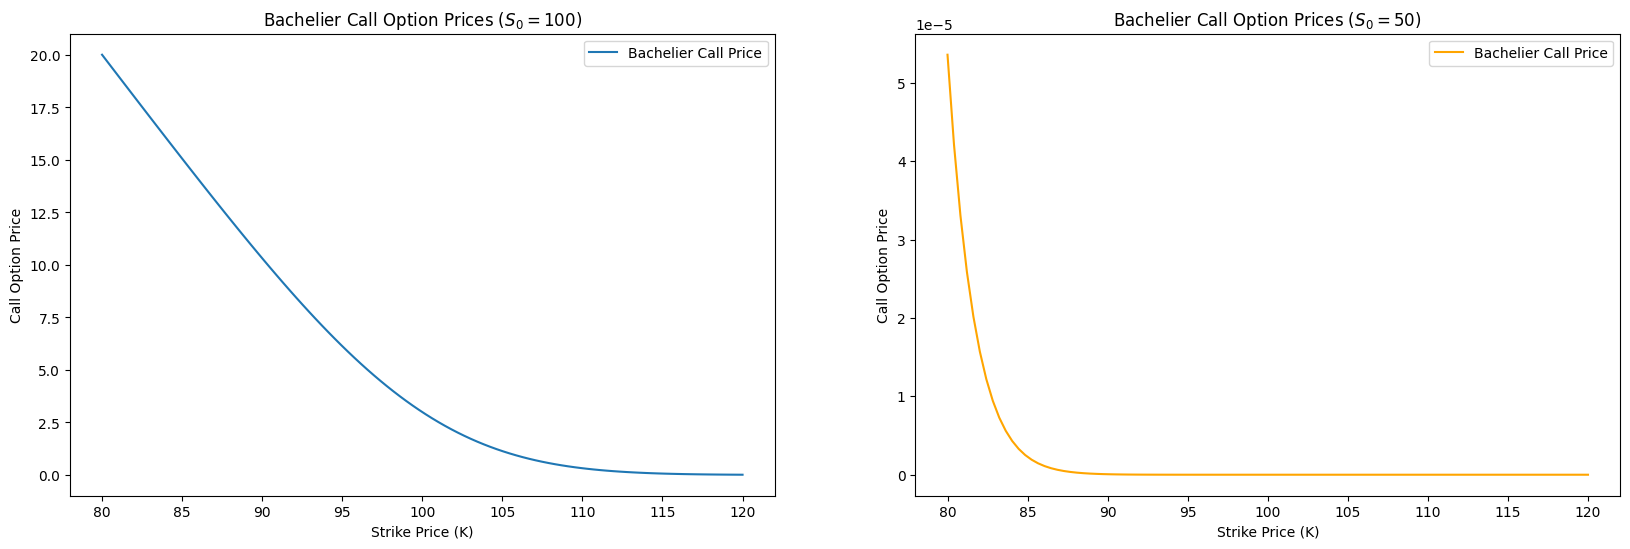

In [6]:
def Bachelier_calls(K, S0, T, sigma):
    d = (S0 - K) / (sigma * np.sqrt(T))
    call_price =  (S0 - K) * stats.norm.cdf(d) + sigma * np.sqrt(T) * stats.norm.pdf(d)
    return call_price

K_vals = np.linspace(80, 120, 100)


call_prices_1 = Bachelier_calls(K_vals, S0 = 100, T = 0.25, sigma = 15)
call_prices_2 = Bachelier_calls(K_vals, S0 = 50, T = 0.25, sigma = 15)

fig, ax = plt.subplots(1, 2,figsize=(20, 6))
ax[0].plot(K_vals, call_prices_1, label = 'Bachelier Call Price')
ax[0].set_title('Bachelier Call Option Prices ($S_0=100$)')
ax[0].set_xlabel('Strike Price (K)')
ax[0].set_ylabel('Call Option Price')
ax[0].legend()

ax[1].plot(K_vals, call_prices_2, label = 'Bachelier Call Price', color='orange')
ax[1].set_title('Bachelier Call Option Prices ($S_0=50$)')
ax[1].set_xlabel('Strike Price (K)')
ax[1].set_ylabel('Call Option Price')
ax[1].legend()

plt.show()

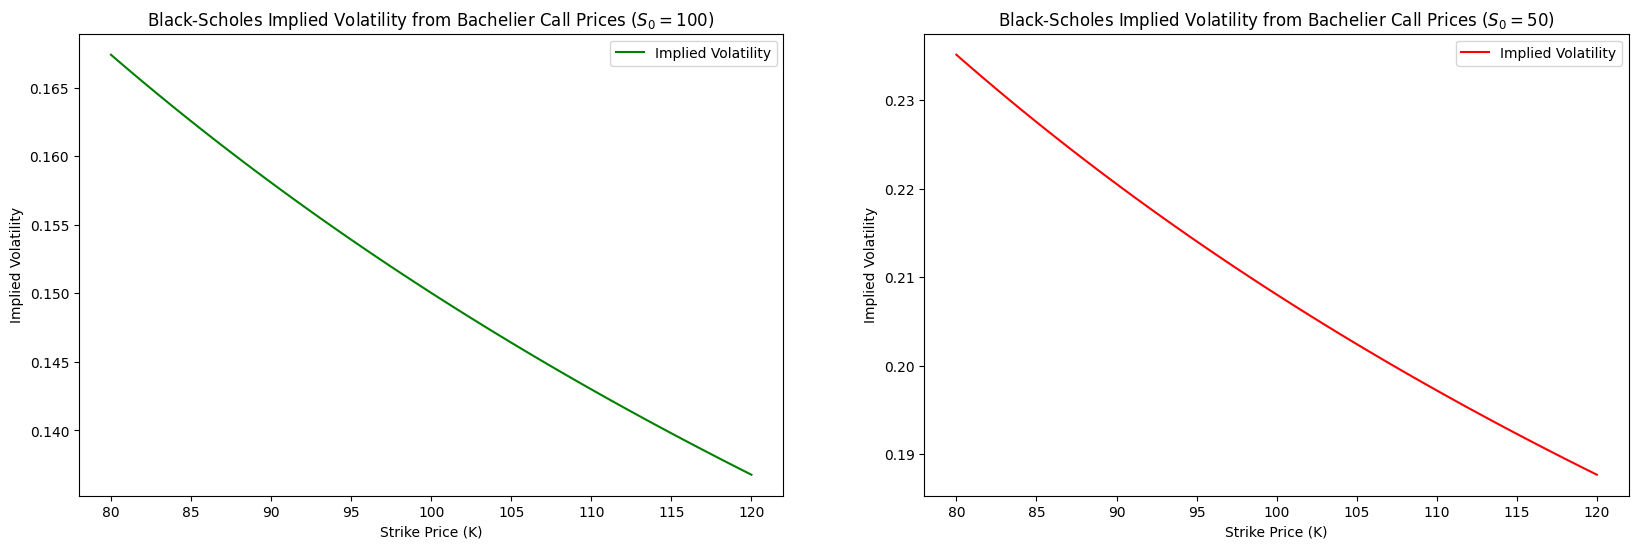

In [7]:
def BlackScholes_calls(K, S0, T, sigma):
    d1 = (np.log(S0 / K) + (sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = S0 * stats.norm.cdf(d1) - K * stats.norm.cdf(d2)
    return call_price

#Bisection method to find implied volatility
def implied_volatility_bisection(K, S0, T, market_price, tol=1e-30, max_iter=1000):
    low_vol = 0.1
    high_vol = 5.0

    for i in range(max_iter):
        mid_vol = (low_vol + high_vol) / 2
        price = BlackScholes_calls(K, S0, T, mid_vol)
        if abs(price - market_price) < tol:
            return mid_vol
        elif price < market_price:
            low_vol = mid_vol
        else:
            high_vol = mid_vol
    return mid_vol

implied_vols_1 = [implied_volatility_bisection(K, 100, 0.25, price) for K, price in zip(K_vals, call_prices_1)]
implied_vols_2 = [implied_volatility_bisection(K, 50, 0.25, price) for K, price in zip(K_vals, call_prices_2)]

fig, ax = plt.subplots(1, 2,figsize=(20, 6))
ax[0].plot(K_vals, implied_vols_1, label = 'Implied Volatility', color='green')
ax[0].set_title('Black-Scholes Implied Volatility from Bachelier Call Prices ($S_0=100$)')
ax[0].set_xlabel('Strike Price (K)')
ax[0].set_ylabel('Implied Volatility')
ax[0].legend()

ax[1].plot(K_vals, implied_vols_2, label = 'Implied Volatility', color='red')
ax[1].set_title('Black-Scholes Implied Volatility from Bachelier Call Prices ($S_0=50$)')
ax[1].set_xlabel('Strike Price (K)')
ax[1].set_ylabel('Implied Volatility')
ax[1].legend()
plt.show()


## 3b)

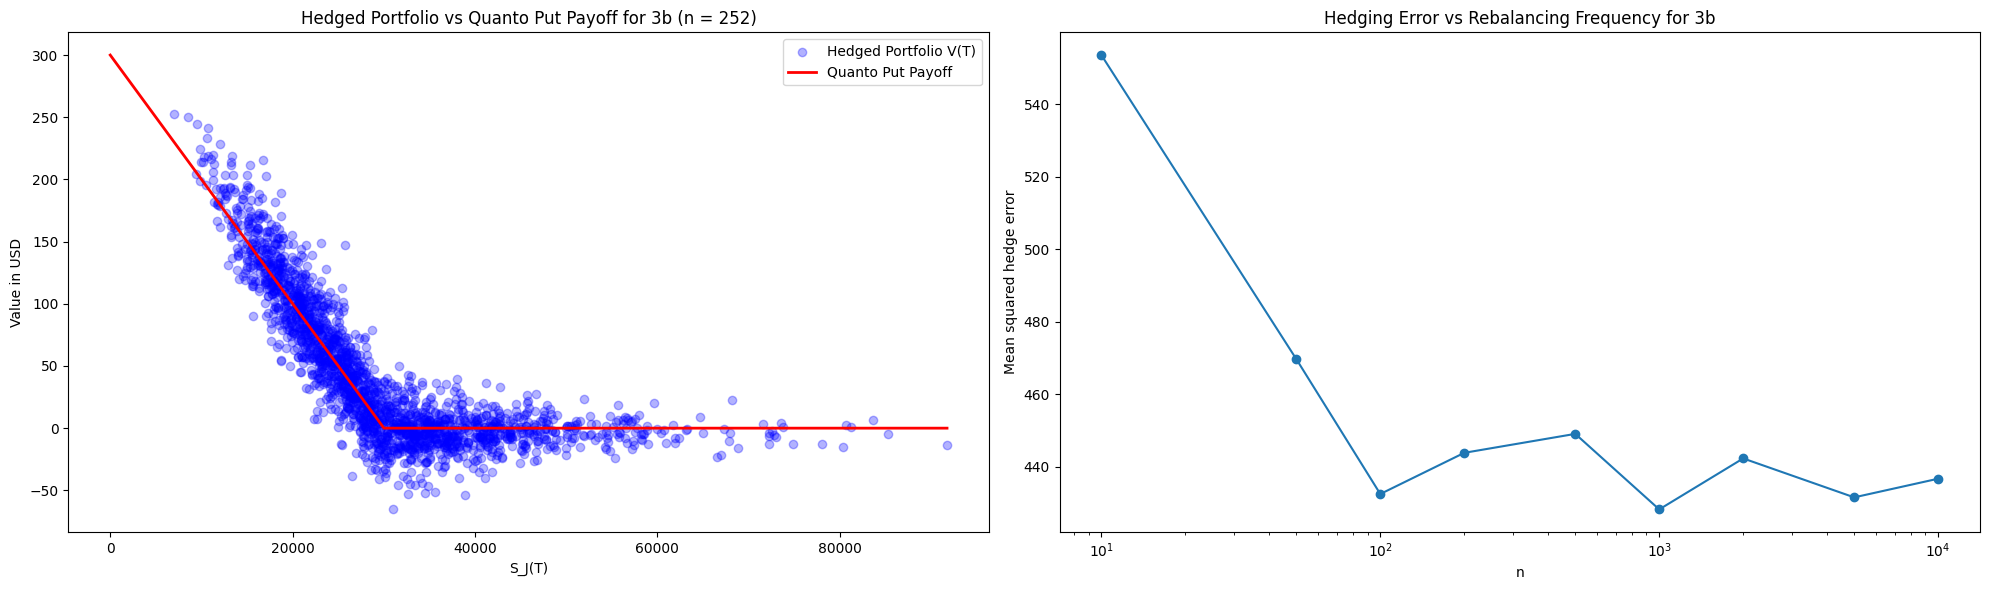

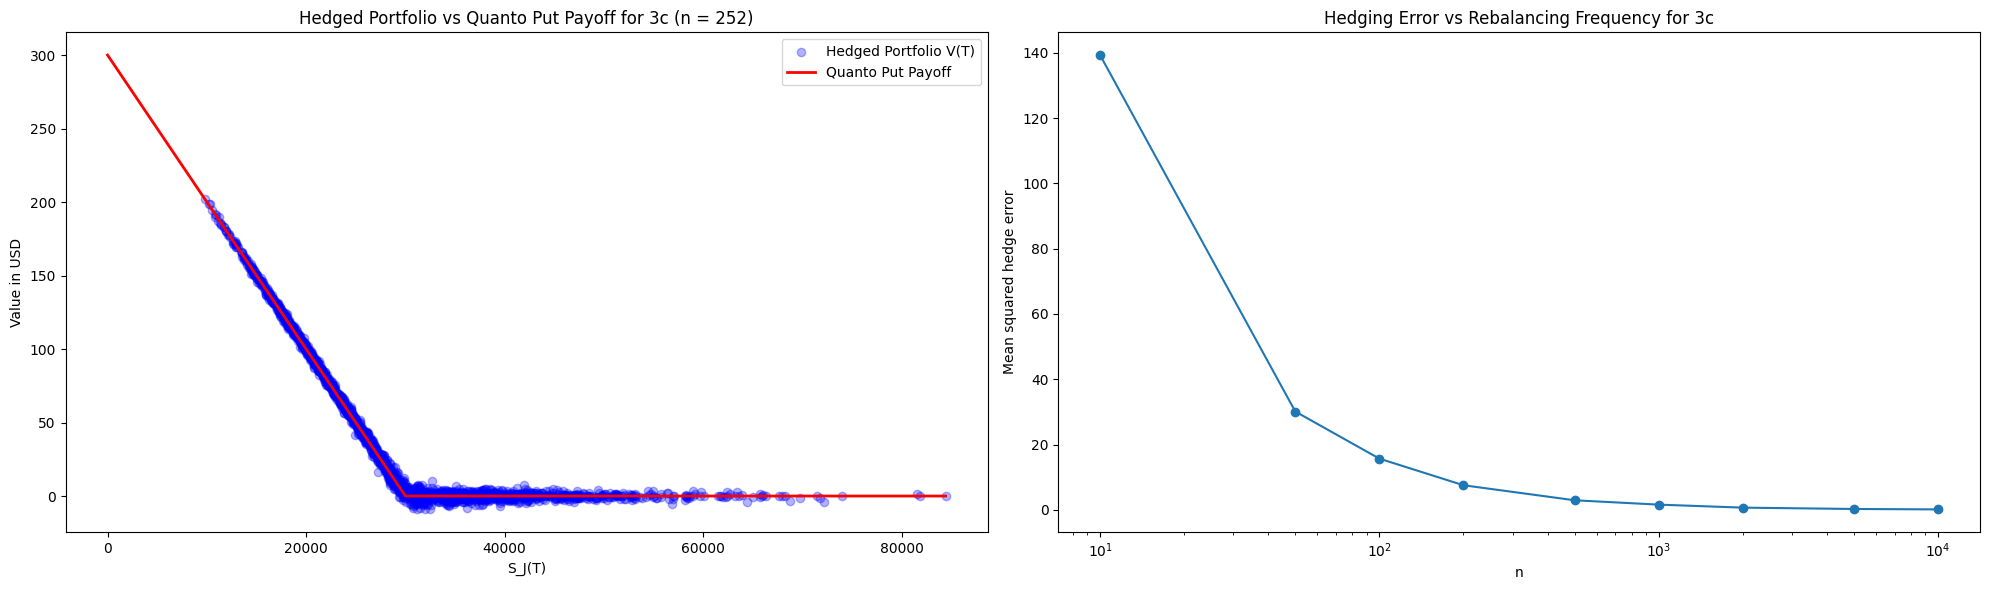

In [13]:
#Global parameters
r_US = 0.03
r_J = 0
sig_X = np.array([0.1, 0.02])
sig_J = np.array([0, 0.25])


S_J0 = 30000
X_0 = 0.01
Y_0 = X_0
K = S_J0
T_max = 2

#Calculate constants for faster runtimes
dot_XJ = sig_X @ sig_J
norm_J = np.linalg.norm(sig_J)
dot_XX = sig_X @ sig_X
dot_JJ = sig_J @ sig_J

#Pricing and hedging functions
def F_QP(t, s, T = T_max):
    d1 = (np.log(s/K) + (r_J - dot_XJ + norm_J**2 / 2) * (T - t))/(norm_J * np.sqrt(T - t))
    d2 = d1 - norm_J * np.sqrt(T - t)
    F = Y_0 * np.exp(-r_US * (T - t)) * (K * stats.norm.cdf(-d2) - s * np.exp((r_J - dot_XJ) * (T - t)) * stats.norm.cdf(-d1))
    return F

def dF_QPds(t, s, T = T_max):
    d1 = (np.log(s/K) + (r_J - dot_XJ + norm_J**2 / 2) * (T - t))/(norm_J * np.sqrt(T - t))
    dFds = Y_0 * np.exp((r_J - dot_XJ - r_US) * (T - t)) * (stats.norm.cdf(d1) - 1)
    return dFds

def Hedge_simulator(hedge_type, n):
    m = 2000 #Number of simulations
    dt = T_max / n
    results = np.zeros((m, 3))

    if hedge_type in ['3b', '3c']:
        mu_X = r_US - r_J
        mu_J = r_J - dot_XJ

    for i in range(m):
        #Initialize simulation
        S_J = S_J0
        X = X_0
        Vpf = F_QP(0, S_J)
        hS_J = dF_QPds(0, S_J)/X
        if hedge_type == '3b':
            hX = 0 #Hedging on currency is not allowed

        elif hedge_type == '3c':
            hX = -hS_J * S_J #Hedging on currency is allowed

        hB_US = Vpf - hS_J * S_J * X - hX * X

        dW = np.random.normal(0, np.sqrt(dt), size = (2, n))
        X = X * np.cumprod(np.exp((mu_X - 0.5 * dot_XX) * dt + sig_X @ dW))
        S_J = S_J * np.cumprod(np.exp((mu_J - 0.5 * dot_JJ) * dt + sig_J @ dW))
        
        for j in range(n):
            Vpf = hS_J * S_J[j] * X[j] + hX * X[j] * np.exp(r_J * dt) + hB_US * np.exp(r_US * dt)

            #Rebalance the hedge
            if j < n-1: #No need to rebalance at the last step
                hS_J = dF_QPds((j + 1) * dt, S_J[j])/X[j]
                if hedge_type == '3b':
                    hX = 0
                elif hedge_type == '3c':
                    hX = -hS_J * S_J[j]
                hB_US = Vpf - hS_J * S_J[j] * X[j] - hX * X[j]

        #Save results
        results[i, 0] = Vpf
        results[i, 1] = Y_0 * max(K - S_J[-1], 0)
        results[i, 2] = S_J[-1]

    return results



#Plotting results for 3b
results = Hedge_simulator('3b', 252)
x_axis = np.arange(1, np.floor(max(results[:, 2])) + 1)

fig, ax = plt.subplots(1, 2, figsize=(20, 6))
ax[0].scatter(results[:,2], results[:,0], color='blue', alpha=0.3, label='Hedged Portfolio V(T)')
ax[0].plot(x_axis, Y_0*np.maximum(K - x_axis,0), color='red', lw=2, label='Quanto Put Payoff')
ax[0].set_xlabel('S_J(T)')
ax[0].set_ylabel('Value in USD')
ax[0].set_title('Hedged Portfolio vs Quanto Put Payoff for 3b (n = %s)' %252)
ax[0].legend()

n_vals = [10, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
errors = []

for n in n_vals:
    results = Hedge_simulator('3b', n)
    hedge_error = results[:,0] - results[:,1]
    errors.append(np.mean(hedge_error**2))

ax[1].plot(n_vals, errors, marker='o')
ax[1].set_xscale('log')
ax[1].set_xlabel('n')
ax[1].set_ylabel('Mean squared hedge error')
ax[1].set_title('Hedging Error vs Rebalancing Frequency for 3b')

plt.tight_layout()
plt.show()

#Plotting results for 3c
results = Hedge_simulator('3c', 252)
x_axis = np.arange(1, np.floor(max(results[:, 2])) + 1)

fig, ax = plt.subplots(1, 2, figsize=(20, 6))
ax[0].scatter(results[:,2], results[:,0], color='blue', alpha=0.3, label='Hedged Portfolio V(T)')
ax[0].plot(x_axis, Y_0*np.maximum(K - x_axis,0), color='red', lw=2, label='Quanto Put Payoff')
ax[0].set_xlabel('S_J(T)')
ax[0].set_ylabel('Value in USD')
ax[0].set_title('Hedged Portfolio vs Quanto Put Payoff for 3c (n = %s)' %252)
ax[0].legend()

n_vals = [10, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
errors = []

for n in n_vals:
    results = Hedge_simulator('3c', n)
    hedge_error = results[:,0] - results[:,1]
    errors.append(np.mean(hedge_error**2))

ax[1].plot(n_vals, errors, marker='o')
ax[1].set_xscale('log')
ax[1].set_xlabel('n')
ax[1].set_ylabel('Mean squared hedge error')
ax[1].set_title('Hedging Error vs Rebalancing Frequency for 3c')

plt.tight_layout()
plt.show()